# Assignment 4 - [DS 215] Introduction to Data Science

\- TA: Purva Parmar (purvaparmar@iisc.ac.in)

Read all the instructions carefully.

- You can create a copy of this notebook and work on Google Colab, or you can download and work locally. If on Google Colab, you can set the Runtime to CPU.
- Put your Student Name and the last five digits of your SR No. in the below cell. (If you do not have an assigned SR No., keep it blank).
- You need to fill in the code between `## TODO START` and `## TODO END` blocks.
- There will be a few `## PLAYGROUND START` and `## PLAYGROUND END` blocks, where you can change parameters inside and see what happens. These are demonstration blocks.
- Do not change any code outside the above two blocks. If there are any issues or clarifications needed, reach out on the Teams channel post or to me personally on Teams Chat.

**Submission Instructions**

- Convert the notebook to a `.py` file
    - If you are on Google Colab, go to `File Menu -> Download -> Download .py`
    - If you are on Jupyter Lab, go to `File Menu -> Save and Export Notebook as -> Executable Script`.
    - If you are on VSCode, there should be an `Export -> Python` option somewhere on the menu bar.
    - For other platforms or situations, consult your favourite LLMs.
    - If still unable to figure out how to do it, inform the TA (I wonder what they are called and where their name might be written) on Teams Chat and submit the `.ipynb` file.
- Rename it as `Student_Name_SRNO_IDS_A4.py`. For example, if your name is Purva Parmar (surely not?) and the last five digits of your SR No. is 24013 (okay I know nobody in this class has this because I checked), rename it to `Purva_Parmar_24013_IDS_A4.py`. Once again, if you do not have an SR No., you can leave it blank like `SR_NO = ""`.
- Submit the python script file to the Assignment tab on Teams.
- If you withdraw your submission and submit a new file, any submission after the first may result Teams automatically setting a number suffix in your filename, like `Purva_Parmar_24013_IDS_A4 1.py `. This is fine and you do not need to worry about it.

**Marks Distribution**

- Section 1: K-Nearest Neighbours [18 marks]
- Section 2: K-Means Clustering [25 marks]
- Section 3: K-Medians Clustering [17 marks]
- Total: 60 marks

For any issues, clarifications or comments, reach out to the TA (Purva) mentioned above on Teams or via email. For all help requests via Teams Chat or email, you must submit any animal photo, that you think is cute, as an offering. (You are allowed to send these offerings even without any help request, by the way)

In [1]:
# ============================================
# Student Information
# ============================================

## TODO START 

# Set this to your official name as per SAP (don't worry about capitalisation)
STUDENT_NAME = "Chethan"

# Set this to the last five digits of your SR No.
# If you do not have an assigned SR No., keep it blank
SR_NO = "25849"

## TODO END

## Imports

If you are working locally, you might want to install `numpy`, `scikit-learn` and `matplotlib` if you do not have them already.

In [2]:
import numpy as np
from collections import Counter, defaultdict
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import heapq
import random

## 1. K Nearest Neighbours (KNN)

### Distance Functions

We will first look at distance measures.

$$ d(x, y) = \sqrt{\sum_{i=1}^N (x_i - y_i)^2} \qquad \text{(Euclidean or $ \mathcal{L}^2 $ Distance)} $$

$$ d(x, y) = \sum_{i=1}^N |x_i - y_i| \qquad \text{(City Block or $ \mathcal{L}^1 $ or Manhattan Distance)} $$

$$ d(x, y) = \left( \sum_{i=1}^N (x_i - y_i)^p \right)^{\frac{1}{p}} \qquad \text{(Minkowski or $\mathcal{L}^p$ Distance)} $$

In [3]:
# ============================================
# Distance Functions
# ============================================

def euclidean_distance(x1: np.ndarray, x2: np.ndarray) -> float:
    """
    Compute the Euclidean (L2) distance between two vectors.

    Args:
        x1 (np.ndarray): 1D array representing the first feature vector. Shape (n_features,).
        x2 (np.ndarray): 1D array representing the second feature vector. Shape (n_features,).

    Returns:
        float: The Euclidean distance between x1 and x2.

    Note:
        You are not allowed to use np.linalg.norm, but you can use other numpy functions
        
    Example:
        >>> euclidean_distance(np.array([0, 0]), np.array([3, 4]))
        5.0
    """
    # Note: You are not allowed to use np.linalg.norm, but you can use other numpy functions
    ## TODO START
    return np.sqrt(np.sum(( x1 - x2 )**2))
    ## TODO END


def manhattan_distance(x1: np.ndarray, x2: np.ndarray) -> float:
    """
    Compute the Manhattan (L1) distance between two vectors.

    Args:
        x1 (np.ndarray): First feature vector, shape (n_features,).
        x2 (np.ndarray): Second feature vector, shape (n_features,).

    Returns:
        float: The Manhattan distance (sum of absolute differences).

    Note:
        You are not allowed to use np.linalg.norm, but you can use other numpy functions
        
    Example:
        >>> manhattan_distance(np.array([1, 2]), np.array([3, 4]))
        4.0
    """
    # Note: You are not allowed to use np.linalg.norm, but you can use other numpy functions
    ## TODO START
    return np.sum(np.abs(x1 - x2))
    ## TODO END


def minkowski_distance(x1: np.ndarray, x2: np.ndarray, p: int = 3) -> float:
    """
    Compute the Minkowski (Lp) distance between two vectors.

    Args:
        x1 (np.ndarray): First feature vector, shape (n_features,).
        x2 (np.ndarray): Second feature vector, shape (n_features,).
        p (int): Power parameter for distance metric. 
                 p=1 → Manhattan, p=2 → Euclidean.

    Returns:
        float: The Minkowski distance between x1 and x2.

    Note:
        You are not allowed to use np.linalg.norm, but you can use other numpy functions
        
    Example:
        >>> minkowski_distance(np.array([0, 0]), np.array([3, 4]), p=3)
        4.497941445275415
    """
    # Note: You are not allowed to use np.linalg.norm, but you can use other numpy functions
    ## TODO START
    return np.sum(np.abs(x1 - x2)**p)**(1/p)
    ## TODO END

In [4]:
## SELF TEST START

# ============================================
# SELF TESTS: Distance Functions
# ============================================

print("\nRunning self-tests for distance functions...")

x1 = np.array([0, 0])
x2 = np.array([3, 4])

# --- Euclidean ---
assert np.isclose(euclidean_distance(x1, x2), 5.0), "❌ Euclidean distance incorrect."

# --- Manhattan ---
assert np.isclose(manhattan_distance(x1, x2), 7.0), "❌ Manhattan distance incorrect."

# --- Minkowski ---
assert np.isclose(minkowski_distance(x1, x2, p=3), (3**3 + 4**3)**(1/3)), "❌ Minkowski distance incorrect."
assert minkowski_distance(x1, x1) == 0, "❌ Distance from a point to itself should be zero."

print("✅ All distance function tests passed!\n")

## SELF TEST END


Running self-tests for distance functions...
✅ All distance function tests passed!



### KNN Classifier

For a given point, we find the distances of this point from all the points in the training set, and take the k nearest neighbours.

From these k nearest neighbours, we take the label which most neighbours have. However, we can also do other interesting things. Suppose we have taken the labels of our k nearest neighbours. Instead of returning the label with the highest count, we can convert the counts of these labels into a probability distribution by dividing the label counts with k. This can give a "fuzzy" or "soft" prediction, depicting the "confidence" the model has in its prediction.

In [5]:
# ============================================
# KNN Classifier
# ============================================

class KNN:
    """
    A simple implementation of the K-Nearest Neighbors classifier.

    Attributes:
        k (int): Number of nearest neighbors to consider.
        distance_metric (str): Distance metric ("euclidean", "manhattan", or "minkowski").
        X_train (np.ndarray): Training feature matrix of shape (n_samples, n_features).
        y_train (np.ndarray): Training labels of shape (n_samples,).
    """

    def __init__(self, k: int = 3, distance_metric: str = "euclidean"):
        """
        Initialize a KNN classifier.

        Args:
            k (int): Number of neighbors to consider.
            distance_metric (str): Distance metric to use: "euclidean", "manhattan", or "minkowski".

        Raises:
            ValueError: If an unsupported distance metric is provided.
        """
        self.k = k
        self.distance_metric = distance_metric
        self.X_train = None
        self.y_train = None

        if self.k < 1:
            raise ValueError(f"k needs to be at least 1, as we need to consider at least one neighbour. Current Value: {k}")

    def fit(self, X: np.ndarray, y: np.ndarray):
        """
        Memorize the training data (lazy learner — no actual model training).

        Args:
            X (np.ndarray): Training features, shape (n_samples, n_features).
            y (np.ndarray): Training labels, shape (n_samples,).
        """
        self.X_train = X
        self.y_train = y

    def _compute_distance(self, x1: np.ndarray, x2: np.ndarray) -> float:
        """
        Compute the distance between two samples based on the selected metric.

        Args:
            x1, x2 (np.ndarray): Feature vectors of equal shape.

        Returns:
            float: Computed distance value.

        Raises:
            ValueError: If the distance metric is not recognized.
        """
        if self.distance_metric == "euclidean":
            return euclidean_distance(x1, x2)
        elif self.distance_metric == "manhattan":
            return manhattan_distance(x1, x2)
        elif self.distance_metric == "minkowski":
            return minkowski_distance(x1, x2)
        else:
            raise ValueError(f"Unsupported metric: {self.distance_metric}")

    def _predict_single_fuzzy(self, x: np.ndarray) -> dict:
        """
        Compute a "fuzzy" prediction for a single sample by returning class confidences
        based on the proportion of neighbor labels.

        Args:
            x (np.ndarray): Single input sample, shape (n_features,).

        Returns:
            dict: A dictionary mapping each class label to its confidence score 
                  (proportion of neighbors belonging to that class).

        Example:
            >>> # Suppose nearest neighbors have labels [1, 1, 0, 1, 0]
            >>> model._predict_single_fuzzy(x)
            {1: 0.6, 0: 0.4}
        """
        ## TODO START
        confidence_scores = defaultdict(int)
        n = x.shape[0]
        
        for i in x:
            confidence_scores[i] += 1
        
        for key in confidence_scores.keys():
            confidence_scores[key] /= n
            
        return confidence_scores
        ## TODO END

    def _predict_single(self, x: np.ndarray):
        """
        Predict the label for a single test sample.

        Args:
            x (np.ndarray): Single input sample, shape (n_features,).

        Returns:
            int or str: Predicted class label.
        """
        ## TODO START
        # Heap to store k nearest neighbors
        priority_queue = []

        for neighbor,neighbor_label in zip(self.X_train,self.y_train):
            # Add the neighbor to heap
            heapq.heappush(priority_queue, (-self._compute_distance(neighbor,x), neighbor_label))

            # Keep only K-nearest neighbors
            if len(priority_queue) > self.k:
                heapq.heappop(priority_queue)

        neighbour_labels = [item[1] for item in priority_queue]
        # Compute confidence scores
        confidence_scores = self._predict_single_fuzzy(np.array(neighbour_labels))
        
        return max(confidence_scores, key=confidence_scores.get) 
        
        ## TODO END

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict class labels for multiple samples.

        Args:
            X (np.ndarray): Test feature matrix, shape (n_samples, n_features).

        Returns:
            np.ndarray: Predicted labels, shape (n_samples,).

        Example:
            >>> model = KNN(k=3)
            >>> model.fit(X_train, y_train)
            >>> preds = model.predict(X_test)
        """
        return np.array([self._predict_single(x) for x in X])

In [6]:
## SELF TEST START

# ============================================
# SELF TESTS: KNN
# ============================================

print("Running self-tests for KNN...")

# Create a small dataset
X_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_train = np.array([0, 0, 1, 1])

knn = KNN(k=3, distance_metric="euclidean")
knn.fit(X_train, y_train)

# Shape checks
assert knn.X_train.shape == X_train.shape, "❌ X_train shape not stored correctly."
assert knn.y_train.shape == y_train.shape, "❌ y_train shape not stored correctly."

# Prediction sanity
x_test = np.array([[0.9, 0.9]])
pred = knn.predict(x_test)
assert pred.shape == (1,), "❌ Prediction output should be a 1D array of shape (n_samples,)."
assert pred[0] in [0, 1], "❌ Predicted class must be one of the training labels."

# Fuzzy prediction
fuzzy = knn._predict_single_fuzzy(np.array([0.9, 0.9]))
assert isinstance(fuzzy, dict), "❌ Fuzzy prediction should return a dictionary."
assert np.isclose(sum(fuzzy.values()), 1.0), "❌ Fuzzy confidences should sum to 1.0 (approximately)."

print("✅ All KNN tests passed!\n")

## SELF TEST END

Running self-tests for KNN...
✅ All KNN tests passed!



### Demonstration of KNN

In [7]:
# ============================================
# Data Generation & Demonstration Utilities
# ============================================

def generate_2d_dataset(dataset_type: str = "clusters", class_weights: tuple = (0.5, 0.5), seed_modifier: int = 0):
    """
    Generate a synthetic 2-class dataset for demonstration using sklearn's `make_classification`.

    The SR_NO is used as the base seed to ensure each student receives unique data.

    Args:
        dataset_type (str): Type of dataset to create, can be "clusters" or "moons"
        class_weights (tuple[int]): Proportion of samples in each class. Can be used to create imbalanced datasets
        seed_modifier (int): Optional integer added to SR_NO for variation (default 0).

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
            (X_train, X_test, y_train, y_test)
    """
    global SR_NO

    sr_no_copy = SR_NO
    
    if len(sr_no_copy) == 0:
        sr_no_copy = 22025

    sr_no_copy = int(sr_no_copy)
    
    seed = sr_no_copy + seed_modifier

    if dataset_type == "clusters":
        X, y = make_classification(
            n_samples=200,
            n_features=2,
            n_informative=2,
            n_redundant=0,
            n_clusters_per_class=2,
            n_classes=2,
            weights=class_weights,
            random_state=seed
        )
    elif dataset_type == "moons":
        X, y = make_moons(
            n_samples=tuple(int(200*i) for i in class_weights),
            noise=seed/1.5e5,
            random_state=seed
        )
    else:
        raise ValueError(f"Unsupported dataset type: {dataset_type}. Please use 'clusters' or 'moons'.")
        
    return train_test_split(X, y, test_size=0.2, random_state=seed)


def plot_decision_boundary(model: KNN, X: np.ndarray, y: np.ndarray, ax=None, title=""):
    """
    Plot KNN decision boundary for 2D dataset.

    Args:
        model (KNN): Trained KNN model.
        X (np.ndarray): Input data, shape (n_samples, 2).
        y (np.ndarray): Labels, shape (n_samples,).
        ax (matplotlib.axes.Axes): Axis to draw on (optional).
        title (str): Title for the plot.
    """
    if ax is None:
        ax = plt.gca()

    # Define bounds
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Create a mesh grid
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid_points).reshape(xx.shape)

    # Decision surface
    ax.contourf(xx, yy, preds, alpha=0.3, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors="k")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

def compare_k_values(metric: str = "euclidean", dataset_type: str = "clusters", class_weights: tuple = (0.5, 0.5), k_values=(1, 3, 7, 15)):
    """
    Compare decision boundaries across multiple k values.

    Args:
        metric (str): Distance metric to use.
        dataset_type (str): Type of dataset to create, 'clusters' or 'moons'.
        class_weights (tuple[float]): Proportion of samples from each class. Can be used to create imbalanced datasets.
        k_values (tuple[int]): List of k values to visualize.
    """
    X_train, X_test, y_train, y_test = generate_2d_dataset(dataset_type, class_weights)

    fig, axes = plt.subplots(1, len(k_values), figsize=(4 * len(k_values), 4))
    for ax, k in zip(axes, k_values):
        model = KNN(k=k, distance_metric=metric)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        plot_decision_boundary(model, X_train, y_train, ax=ax,
                               title=f"k={k}\nAcc={acc:.2f}")
    plt.suptitle(f"Effect of k on Decision Boundary ({metric.capitalize()} Distance)", fontsize=14)
    plt.tight_layout()
    plt.show()

#### Playing with KNN

You can play around with the below cell. Try setting the `dataset_type` to `clusters` or `moons`, and play with the `class_weights`. KNN can underperform when the dataset is heavily imbalanced. You can try this with setting `class_weights=(0.95, 0.05)`.

KNN is inefficient because it has to use the entire dataset for prediction each time. But, it generally works well even with cases where K Means might falter, like two classes which form moons.

The Accuracy in some of these graphs might show 1.00 even if the decision boundary implies that there are misclassifications. This is due to the way the train-test split is created. The accuracy is returned on the test set prediction, which is 30% of 200 samples.

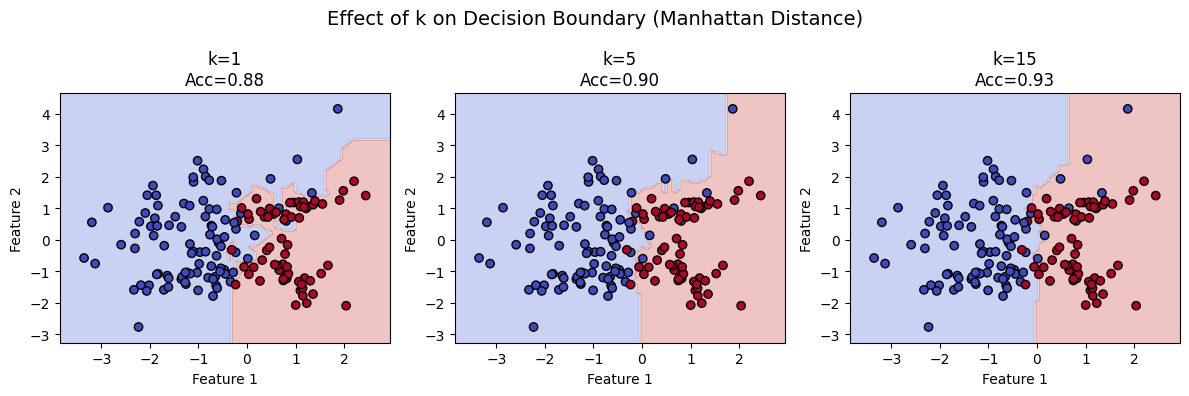

In [8]:
## PLAYGROUND START

# You can play around with this.
# metrics can be "manhattan" or "euclidean" (or "minkowski" which defaults to p=3)
# dataset_type can be "clusters" or "moons"

compare_k_values(metric="manhattan", dataset_type = "clusters", class_weights=np.array((0.6, 0.4)), k_values=(1, 5, 15))

## PLAYGROUND END

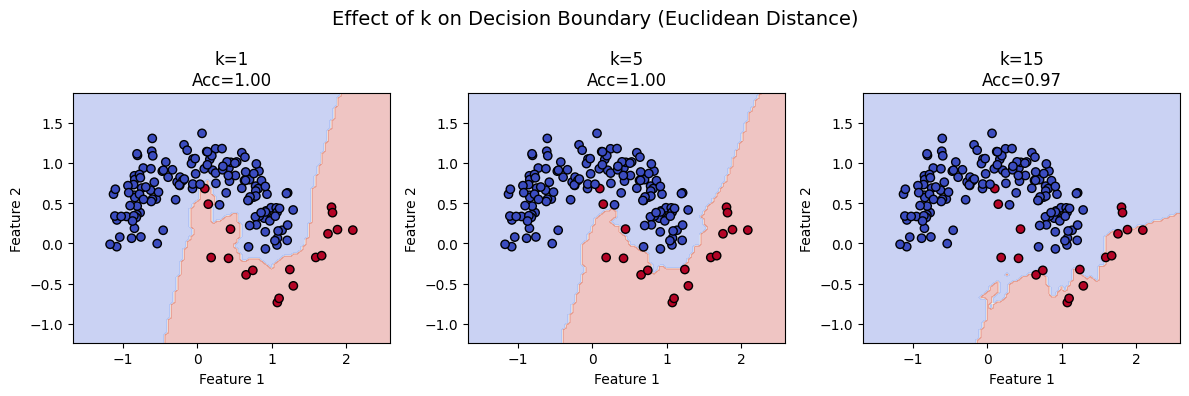

In [9]:
## PLAYGROUND START

# You can play around with this.
# metrics can be "manhattan" or "euclidean" (or "minkowski" which defaults to p=3)
# dataset_type can be "clusters" or "moons"
# KNN can underperform when the dataset is heavily imbalanced. You can try this with setting `class_weights=(0.95, 0.05)`.

compare_k_values(metric="euclidean", dataset_type = "moons", class_weights=(0.9, 0.1), k_values=(1, 5, 15))

## PLAYGROUND END

## 2. K-Means Clustering

In this section, we will implement the K-Means clustering algorithm.

K-Means aims to partition the data into `k` clusters such that each point belongs to the cluster with the nearest centroid.

We will initialize the centroids by randomly picking k points from the dataset itself.

The algorithm alternates between:
1. Assigning points to the nearest centroid.
2. Updating centroids as the mean of assigned points.

We will implement helper functions and the KMeans class.

Note some key differnces from KNN. Unlike KNN, KMeans is *unsupervised*. It does not use any labels, whereas KNN uses the entire training set and its labels to make predictions. Another key difference is that KNN is primarily a classification method, while K-Means is a clustering method. In K-Means, we do not know how many clusters even exist in the data, we just give the method a value of `k` and ask it to find those k cluster centroids. Consult your favourite (or disliked, I am not judging) LLMs for more insights. Especially useful are variations of KNNs and K-Means asked in placement interviews. Would be good to have an idea of what all you can do with these methods.

**Note: You are allowed to use any numpy function (including `np.linalg.norm`) from here on.**

### K-Means Class


In [10]:
class KMeans:
    
    def __init__(self, k: int = 3, max_iters: int = 100, tol: float = 1e-4, seed: int = 42):
        """
        Initialize the KMeans clustering model.

        Args:
            k (int): The number of clusters to form.
            max_iters (int): The maximum number of iterations to run the algorithm.
            tol (float): The convergence threshold. If the centroids move less than this
                         distance between iterations, we consider the algorithm converged.
            seed (int): Random seed for reproducibility.

        Note:
            - The actual fitting (clustering) is done by calling `fit(X)`.
            - Centroids and labels are initialized as None until `fit()` is run.
        """
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.seed = seed
        self.centroids = None
        self.labels_ = None    # Cluster label for each data point, shape (n_samples,).

    # ----------------------------------------------------------------------
    # Internal helper functions — each represents a single logical step
    # ----------------------------------------------------------------------

    def _initialize_centroids(self, X: np.ndarray) -> np.ndarray:
        """
        Randomly choose `k` samples from X as initial centroids.

        Args:
            X (np.ndarray): Dataset, shape (n_samples, n_features).

        Returns:
            np.ndarray: Initial centroids, shape (k, n_features).

        Explanation:
            - The simplest (and most common) initialization is to pick `k` random data points as starting centroids.
            - Setting a random seed ensures reproducibility (i.e., same initial centroids if you run it again with the same seed).
        
        Note:
            - Consider handling the edge case when we have more clusters than samples, i.e. self.k > X.shape[0].
            Hint: You can sample from the data points with replacement (as in, you can have multiple centroids 
            initialized to the same data point).
        """
        np.random.seed(self.seed)

        ## TODO START
        indices = np.random.randint(0, X.shape[0], size=self.k)
        return X[indices]
        ## TODO END

    def _assign_clusters(self, X: np.ndarray, centroids: np.ndarray) -> np.ndarray:
        """
        Assign each data point to the nearest centroid (cluster).

        Args:
            X (np.ndarray): Dataset, shape (n_samples, n_features).
            centroids (np.ndarray): Current centroids, shape (k, n_features).

        Returns:
            np.ndarray: Cluster index (0 to k-1) for each sample, shape (n_samples,).

        Explanation:
            - For each sample in X, compute its distance from each centroid.
            - Use Euclidean distance: sqrt(sum((x_i - c_j)^2))
            - The sample is assigned to the cluster whose centroid is closest.

        Note: Computing distance between the centroids and each points in a vectorized fashion can be unintuitive.
        You might be using broadcasting, in which case I suggest you take a pen and a paper, and write out the dimensions,
        and see how they are being broadcasted and what they mean. Consult your favourite LLMs for detailed explanations.
        """
        ## TODO START
        clusters = np.zeros(X.shape[0],dtype=np.int64)
        for idx,x in enumerate(X):
            best_cluster = None
            min_distance_sq = np.inf
            for cluster_idx in range(centroids.shape[0]):
                distance_sq = np.square(np.sum((x-centroids[cluster_idx])**2))
                if min_distance_sq > distance_sq:
                    best_cluster = cluster_idx
                    min_distance_sq = distance_sq
            clusters[idx] = best_cluster
        return clusters  
        ## TODO END

    def _update_centroids(self, X: np.ndarray, labels: np.ndarray) -> np.ndarray:
        """
        Compute new centroids as the mean of points assigned to each cluster.

        Args:
            X (np.ndarray): Dataset, shape (n_samples, n_features).
            labels (np.ndarray): Cluster assignment for each sample, shape (n_samples,).

        Returns:
            np.ndarray: Updated centroids, shape (k, n_features).

        Explanation:
            - For each cluster `i`, take all points in X that were assigned to cluster `i`.
            - Compute the mean of those points along each feature dimension.
        """
        ## TODO START
        centroids = np.zeros((self.k,X.shape[1]))

        # Array to store the count of member in each cluster
        counts = defaultdict(int)

        # Compute sum along each dimenion
        for idx in range(X.shape[0]):
            centroid_idx = labels[idx]
            centroids[centroid_idx,:] += X[idx]
            counts[centroid_idx] += 1

        # Compute mean
        for centroid_idx,count in counts.items():
            centroids[centroid_idx] /= count
            
        return centroids
        ## TODO END

    def _has_converged(self, old_centroids: np.ndarray, new_centroids: np.ndarray) -> bool:
        """
        Check if centroids have moved less than the convergence threshold (tol).

        Args:
            old_centroids (np.ndarray): Centroids from previous iteration.
            new_centroids (np.ndarray): Centroids from current iteration.

        Returns:
            bool: True if shift < tol, otherwise False.

        Explanation:
            - Compute total shift = L2 norm of the difference between old and new centroids.
            - If this movement is below tolerance, the algorithm is considered converged.
        """
        ## TODO START
        return np.linalg.norm(old_centroids - new_centroids,ord=2) < self.tol
        ## TODO END

    # ----------------------------------------------------------------------
    # Main training and prediction methods
    # ----------------------------------------------------------------------

    def fit(self, X: np.ndarray):
        """
        Run the K-Means clustering algorithm on dataset X.

        Args:
            X (np.ndarray): Input dataset, shape (n_samples, n_features).

        Steps Performed:
            1. Initialize centroids randomly from X using self._initialize_centroids()
            2. Repeat for at most `max_iters` iterations:
                a. Assign each data point to the nearest centroid using self._assign_clusters()
                b. Update centroids as the mean of their assigned points with self._update_centroids()
                c. Check for convergence (centroid movement < tol) with self._has_converged()
                   If converged, stop early to save computation.

        After Fitting (Make sure these are assigned by the end):
            - self.centroids: Final cluster centers.
            - self.labels_: Cluster labels for each data point.
        """
        ## TODO START
        self.pre_centroids = None
        centroids = self._initialize_centroids(X)
        iterations = 0
        new_centroids = None
        while iterations < self.max_iters:
            labels = self._assign_clusters(X,centroids)
            new_centroids = self._update_centroids(X, labels)
            if self._has_converged(centroids, new_centroids):
                break
            centroids = new_centroids
        self.centroids = new_centroids
        self.labels_ = labels
        ## TODO END

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict the nearest cluster index for each data point.

        Args:
            X (np.ndarray): New data, shape (n_samples, n_features).

        Returns:
            np.ndarray: Predicted cluster indices (0 to k-1), shape (n_samples,).

        Usage:
            - Can be used on unseen data after fitting the model.
            - Simply assigns each point to the closest of the already-learned centroids.
        """
        return self._assign_clusters(X, self.centroids)


In [11]:
## SELF TEST START

# ============================================
# SELF TESTS: KMeans
# ============================================

print("Running self-tests for KMeans...")

# Simple blob dataset
X = np.array([[1, 2], [1, 4], [5, 2], [5, 4]])

model = KMeans(k=3, max_iters=10, tol=1e-4, seed=42)
model.fit(X)

# Basic sanity
assert model.centroids.shape == (3, 2), "❌ Centroids shape should be (k, n_features)."
assert model.labels_.shape == (X.shape[0],), "❌ labels_ shape should match number of samples."

# Centroid convergence check (just runs, not infinite loop)
assert hasattr(model, "centroids"), "❌ Model should store centroids after fit."
assert np.all(np.isfinite(model.centroids)), "❌ Centroids contain non-finite values."

# Predict shape
preds = model.predict(X)
assert preds.shape == (X.shape[0],), "❌ Predict output shape mismatch."
assert np.all((preds >= 0) & (preds < model.k)), "❌ Predicted cluster indices out of range."

print("✅ All KMeans tests passed!\n")

## SELF TEST END

Running self-tests for KMeans...
✅ All KMeans tests passed!



### Demonstration of K-Means

In [12]:
# ============================================
# KMeans Visualization Utilities
# ============================================

from sklearn.datasets import make_blobs, make_moons, make_classification

def generate_2d_dataset_kmeans(dataset_type: str = "blobs", seed_modifier: int = 0):
    """
    Generate a synthetic 2D dataset for clustering visualization.

    Args:
        dataset_type (str): "blobs", "moons", or "clusters"
        seed_modifier (int): Optional integer added to SR_NO for variation.

    Returns:
        np.ndarray: Data matrix (n_samples, 2)
    """
    global SR_NO
    sr_no_copy = int(SR_NO) if len(SR_NO) else 22025
    seed = sr_no_copy + seed_modifier

    if dataset_type == "blobs":
        X, _ = make_blobs(
            n_samples=250,
            centers=3,
            n_features=2,
            cluster_std=1.0,
            random_state=seed
        )
    elif dataset_type == "moons":
        X, _ = make_moons(
            n_samples=250,
            noise=0.1,
            random_state=seed
        )
    elif dataset_type == "clusters":
        X, _ = make_classification(
            n_samples=250,
            n_features=2,
            n_informative=2,
            n_redundant=0,
            n_clusters_per_class=1,
            n_classes=3,
            random_state=seed
        )
    else:
        raise ValueError(f"Unsupported dataset type: {dataset_type}")
    return X


def plot_kmeans_clusters(X: np.ndarray, model: KMeans, ax=None, title=""):
    """
    Visualize K-Means clustering results.

    Args:
        X (np.ndarray): Dataset of shape (n_samples, 2).
        model (KMeans): Fitted KMeans model.
        ax (matplotlib.axes.Axes): Optional axis.
        title (str): Plot title.
    """
    if ax is None:
        ax = plt.gca()

    labels = model.labels_
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=30, alpha=0.7)
    ax.scatter(model.centroids[:, 0], model.centroids[:, 1], c="black", s=150, marker="x")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


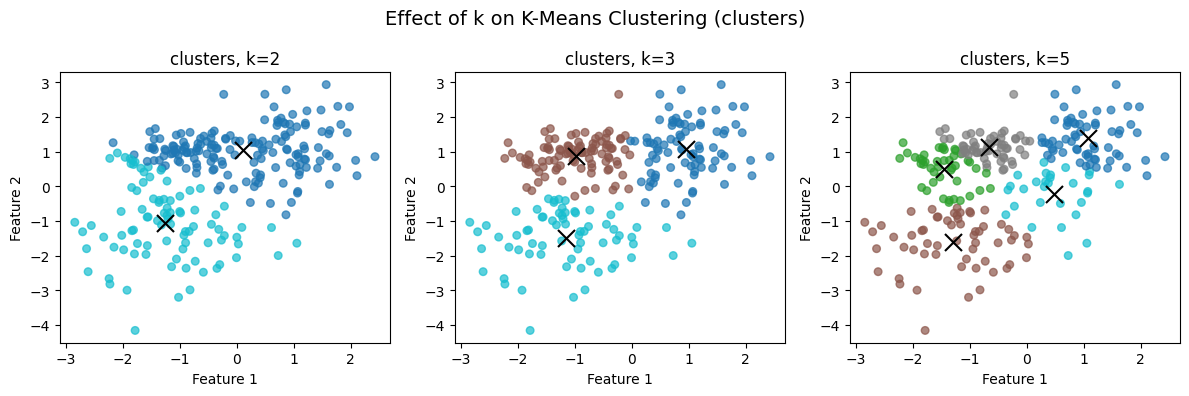

In [13]:
# ============================================
# Demonstration of KMeans
# ============================================

## PLAYGROUND START

# Try changing the dataset type: "blobs", "moons", or "clusters"
dataset_type = "clusters"
X = generate_2d_dataset_kmeans(dataset_type, seed_modifier=10)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, k in zip(axes, [2, 3, 5]):
    model = KMeans(k=k, max_iters=100)
    model.fit(X)
    plot_kmeans_clusters(X, model, ax, title=f"{dataset_type}, k={k}")

plt.suptitle(f"Effect of k on K-Means Clustering ({dataset_type})", fontsize=14)
plt.tight_layout()
plt.show()

## PLAYGROUND END


## 3. K-Medians Clustering

K-Means is sensitive to outliers. Suppose you are an analyst looking at transactions for a large bank. You might find extreme outliers (transactions of crores of rupees as compared to mostly small ones). Since the centroid update relies on finding the mean of its cluster points, it can deviate heavily due to outliers.

Using a median update rule instead of means is a robust strategy against outliers. Here, when updating the centroids, we compute the new centroids as the median of their cluster points.

In [14]:
# ============================================
# KMedians Class Implementation
# ============================================

import numpy as np

class KMedians(KMeans):
    """
    A simple implementation of the K-Medians clustering algorithm.

    K-Medians is similar to K-Means, except:
        - It uses the **median** (not mean) of points within each cluster when updating the centroids.
        - It typically uses the **Manhattan distance** (L1 norm) instead of the Euclidean distance (L2 norm).

    As a result:
        - K-Medians is more robust to outliers (since the median is less affected by extreme values).
        - It can form more compact clusters when data has skewed or heavy-tailed distributions.

    This class inherits most of its logic from KMeans and only overrides:
        - `_assign_clusters`: to use Manhattan distance.
        - `_update_centroids`: to use the median instead of the mean.
    """

    def _assign_clusters(self, X: np.ndarray, centroids: np.ndarray) -> np.ndarray:
        """
        Assign each data point to the nearest centroid using Manhattan (L1) distance.

        Args:
            X (np.ndarray): Dataset, shape (n_samples, n_features).
            centroids (np.ndarray): Current centroids, shape (k, n_features).

        Returns:
            np.ndarray: Cluster index (0 to k-1) for each sample, shape (n_samples,).

        Explanation:
            - For each sample in X, compute its L1 distance from each centroid:
                  distance = sum(|x_i - c_j|)
            - Assign each sample to the cluster with the smallest distance.
            - Using L1 instead of L2 makes this algorithm less sensitive to outliers.
        """
        ## TODO START
        clusters = np.zeros(X.shape[0],dtype=np.int64)
        for idx,x in enumerate(X):
            best_cluster = None
            min_distance = np.inf
            for cluster_idx in range(centroids.shape[0]):
                distance = np.sum(np.abs(x-centroids[cluster_idx]))
                if min_distance > distance:
                    best_cluster = cluster_idx
                    min_distance = distance
            clusters[idx] = best_cluster
        return clusters  
        ## TODO END

    def _update_centroids(self, X: np.ndarray, labels: np.ndarray) -> np.ndarray:
        """
        Compute new centroids as the **median** of points assigned to each cluster.

        Args:
            X (np.ndarray): Dataset, shape (n_samples, n_features).
            labels (np.ndarray): Cluster assignment for each sample, shape (n_samples,).

        Returns:
            np.ndarray: Updated centroids, shape (k, n_features).

        Explanation:
            - For each cluster `i`, take all points assigned to it.
            - Compute the **median** of those points (along each feature dimension).
            - If a cluster happens to have no points, its centroid is left unchanged.
            - Using median instead of mean makes the algorithm more robust to outliers.
        """
        ## TODO START
            
        # if self.pre_centroids is None:
        #     self.pre_centroids = np.zeros((self.k,X.shape[1]))
            
        # centroids = self.pre_centroids
        centroids = np.zeros((self.k,X.shape[1]))
        
        # Array to store the count of member in each cluster
        counts = defaultdict(list)

        # Compute sum along each dimenion
        for idx in range(X.shape[0]):
            centroid_idx = labels[idx]
            counts[centroid_idx].append(X[idx])

        for i in range(self.k):
            if counts[i]:
                centroids[i] = np.median(np.array(counts[i]), axis=0)

        return centroids
        ## TODO END


In [15]:
## SELF TEST START

# ============================================
# SELF TESTS: KMedians
# ============================================

print("Running self-tests for KMedians...")

X = np.array([[1, 1], [1, 2], [10, 10], [10, 11]])
model = KMedians(k=3, seed=42)
model.fit(X)

# Check shapes
assert model.centroids.shape == (3, 2), "❌ Centroids shape incorrect."
assert model.labels_.shape == (X.shape[0],), "❌ Labels shape incorrect."

print("✅ All KMedians tests passed!\n")

## SELF TEST END

Running self-tests for KMedians...
✅ All KMedians tests passed!



### K-Means vs K-Medians Demonstration

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# ------------------------------------------------------
# Demonstration: KMeans vs KMedians
# ------------------------------------------------------

def demo_kmeans_vs_kmedians():
    """
    Demonstrate the visual difference between K-Means and K-Medians clustering.

    The dataset:
        - Two clear clusters
        - A few strong outliers
    K-Medians tends to handle outliers better and keeps centroids closer to dense regions.

    The output:
        - Two side-by-side scatter plots showing cluster assignments and centroids.
    """
    global SR_NO
    sr_no_copy = int(SR_NO) if len(SR_NO) else 22025
    
    # 1. Generate synthetic data
    X, _ = make_blobs(n_samples=100, centers=2, cluster_std=1.2, random_state=sr_no_copy)

    # Add some outliers far away from the clusters
    rng = np.random.RandomState(sr_no_copy)
    outliers = rng.uniform(low=-50, high=50, size=(20, 2))
    X_with_outliers = np.vstack([X, outliers])

    # 2. Fit both algorithms
    kmeans = KMeans(k=2, seed=sr_no_copy)
    kmeans.fit(X_with_outliers)

    kmedians = KMedians(k=2, seed=sr_no_copy)
    kmedians.fit(X_with_outliers)

    # 3. Plot results
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # K-Means
    axes[0].scatter(X_with_outliers[:, 0], X_with_outliers[:, 1],
                    c=kmeans.labels_, cmap='viridis', s=10)
    axes[0].scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
                    c='red', marker='X', s=100, edgecolor='black')
    axes[0].set_title("K-Means Clustering (uses mean + L2)")
    axes[0].set_xlabel("Feature 1")
    axes[0].set_ylabel("Feature 2")

    # K-Medians
    axes[1].scatter(X_with_outliers[:, 0], X_with_outliers[:, 1],
                    c=kmedians.labels_, cmap='viridis', s=10)
    axes[1].scatter(kmedians.centroids[:, 0], kmedians.centroids[:, 1],
                    c='red', marker='X', s=100, edgecolor='black')
    axes[1].set_title("K-Medians Clustering (uses median + L1)")
    axes[1].set_xlabel("Feature 1")
    axes[1].set_ylabel("Feature 2")

    plt.tight_layout()
    plt.show()


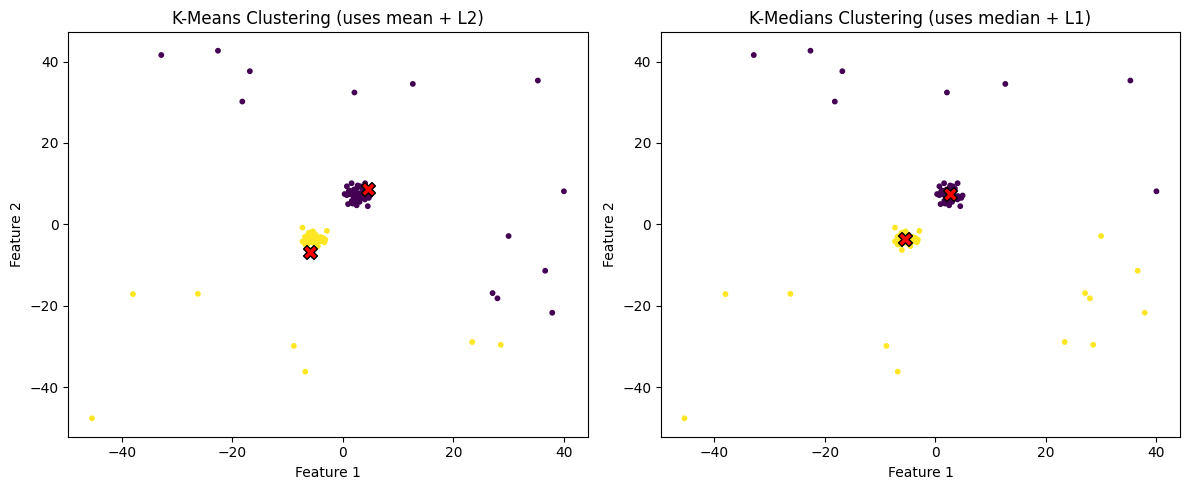

In [17]:
## PLAYGROUND START
# Well there's nothing to modify here though.
# You might notice that in K-Means, the cluster centroids are shifted quite a bit away from the cluster mass. This is due to the outliers
# K-Median Clustering is robust against this.

demo_kmeans_vs_kmedians()

## PLAYGROUND END